
📥 Loading external C-Prior as the Absolute Referee...
📥 Loading and ranking models...
   - Successfully loaded: V1_Base (No Causal Prior)
   - Successfully loaded: MTMT (Multitask Baseline)
   - Successfully loaded: MOTTO (Multitask Baseline2)
   - Successfully loaded: ECUP (CTCVR Baseline)
   - Successfully loaded: V8_S5
   - Successfully loaded: V8_S1_t10
   - Successfully loaded: V6 (multi-head + base)
   - Successfully loaded: V3 (pure multi-head)
   - Successfully loaded: V4 (pure loss)
🧬 Tagging AT, Complier, and NT using extreme percentiles...
   => High P(M=1|T=0) [Always-Taker]: 139796 users
   => High P(M=1|T=1)-P(M|T=0) [Complier]: 55773 users
   => High P(M=0|T=1) [Never-Taker]: 139796 users


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


✅ Rendering plot... (Close the plot window to continue)


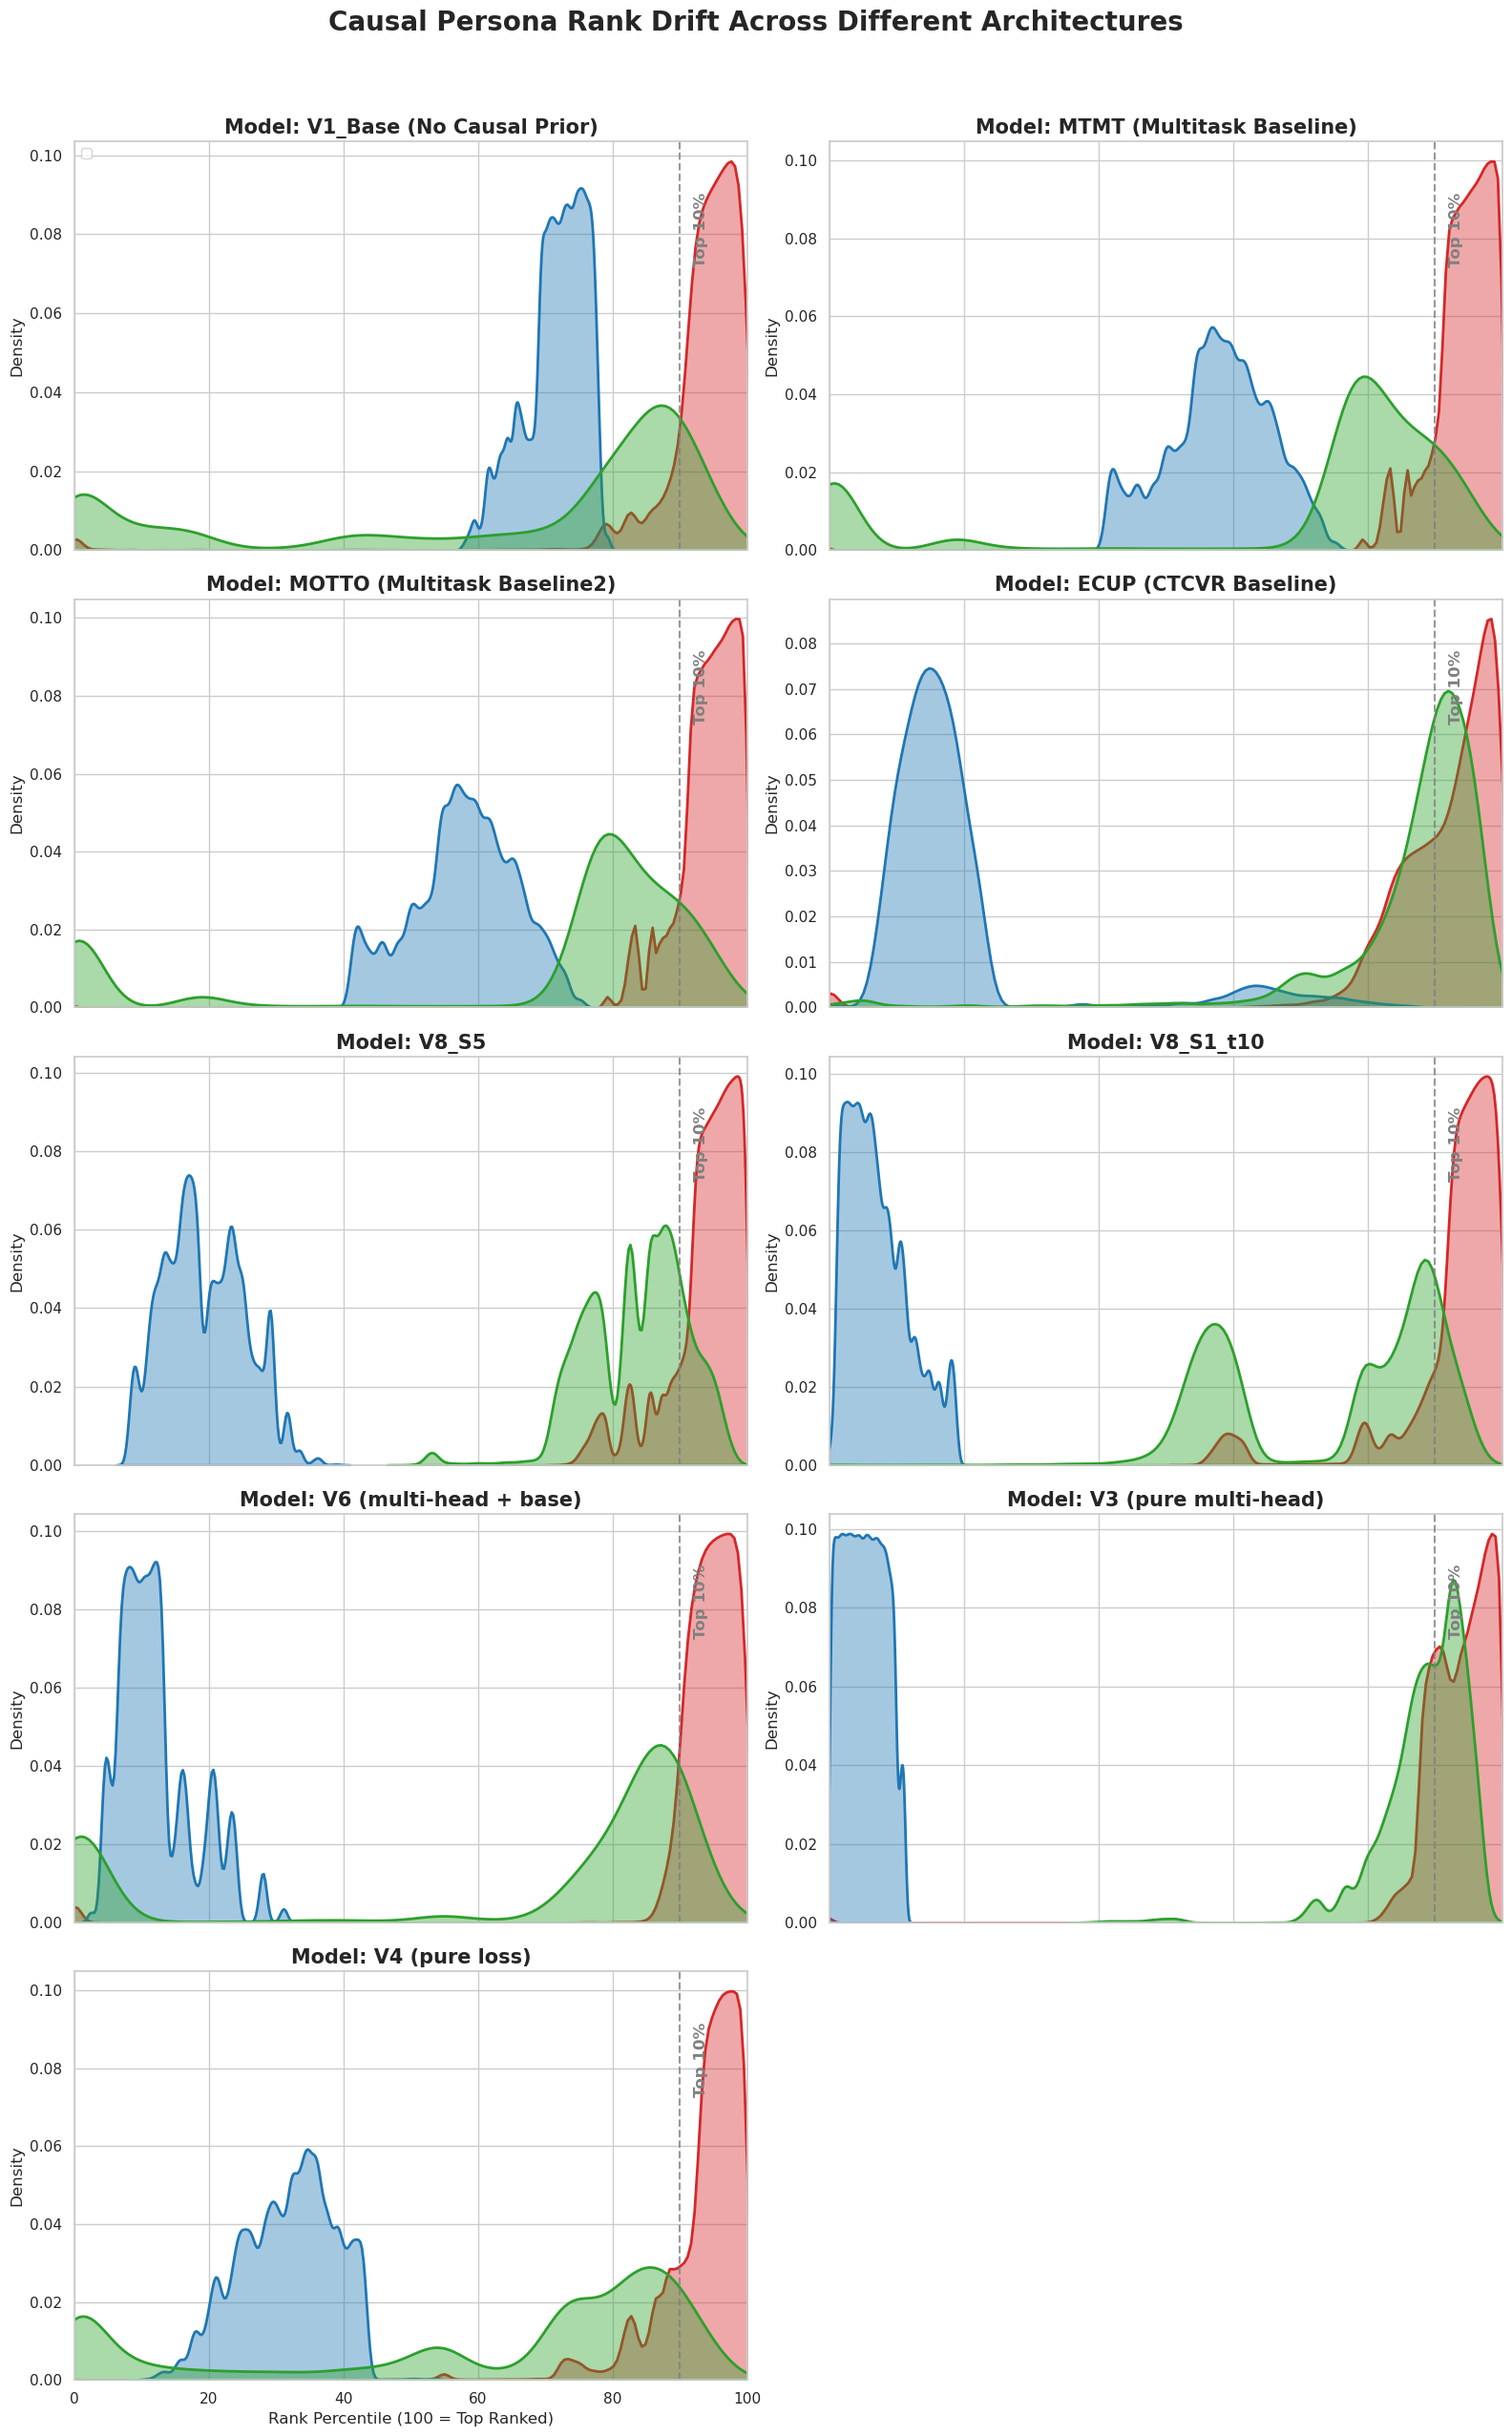

In [16]:
import os
import glob
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 自动路径嗅探
# ==========================================
def resolve_path(pattern):
    """自动解析带 ** 通配符的路径，找到最新的 csv"""
    files = glob.glob(pattern, recursive=True)
    if not files:
        print(f"⚠️ 找不到文件跳过: {pattern}")
        return None
    return files[0]

# ==========================================
# 1. 核心分析类：全景微观追踪器
# ==========================================
class MicroDriftGridAnalyzer:
    def __init__(self, c_pattern, model_paths_dict):
        """
        :param c_pattern: 独立 C 模型先验的路径 (作为裁判)
        :param model_paths_dict: 字典 { "展示的名字": "路径" }
        """
        sns.set_theme(style="whitegrid")
        print("\n📥 Loading external C-Prior as the Absolute Referee...")
        
        c_path = resolve_path(c_pattern)
        if not c_path:
            raise ValueError("C-Prior path is required!")
        self.df_c = pd.read_csv(c_path)
        
        # 提取独立 C 模型的先验物理概率 (上帝视角)
        self.p_always = self.df_c['y0_prob'] # P(M=1 | T=0)
        self.p_comp = np.clip(self.df_c['y1_prob'] - self.df_c['y0_prob'], 0, None)
        self.p_never = np.clip(1.0 - self.df_c['y1_prob'], 0, None) # P(M=0 | T=1)

        # 加载所有对比模型，计算排位
        self.models_data = {}
        print("📥 Loading and ranking models...")
        for name, pattern in model_paths_dict.items():
            path = resolve_path(pattern)
            if path:
                df = pd.read_csv(path)
                # 计算排位：100% = 排在正数第一， 0% = 垫底
                rank_pct = df['uplift_pred'].rank(pct=True) * 100
                self.models_data[name] = rank_pct
                print(f"   - Successfully loaded: {name}")

        self._assign_personas()

    def _assign_personas(self):
        """用上帝视角切分三类极值因果人群"""
        print("🧬 Tagging AT, Complier, and NT using extreme percentiles...")
        
        # 学术级图例定义
        self.label_at = 'High P(M=1|T=0) [Always-Taker]'
        self.label_comp = 'High P(M=1|T=1)-P(M|T=0) [Complier]'
        self.label_nt = 'High P(M=0|T=1) [Never-Taker]'
        
        self.personas = pd.Series('Neutral', index=self.df_c.index)
        
        # 提取极值人群 Top 10%
        th_always = self.p_always.quantile(0.90)
        th_comp = self.p_comp.quantile(0.90)
        th_never = self.p_never.quantile(0.90) 
        
        is_at = self.p_always >= th_always
        # 排他性提纯：金子不能是羊毛党
        is_comp = (self.p_comp >= th_comp) & (~is_at)
        # 绝缘体不能是羊毛党，也不能是金子
        is_nt = (self.p_never >= th_never) & (~is_at) & (~is_comp)
        
        self.personas.loc[is_nt] = self.label_nt
        self.personas.loc[is_at & ~is_comp] = self.label_at
        self.personas.loc[is_comp] = self.label_comp
        
        print(f"   => {self.label_at}: {is_at.sum()} users")
        print(f"   => {self.label_comp}: {is_comp.sum()} users")
        print(f"   => {self.label_nt}: {is_nt.sum()} users")

    def plot_grid(self):
        """动态生成多行两列的对比大图"""
        model_names = list(self.models_data.keys())
        num_models = len(model_names)
        
        if num_models == 0:
            print("❌ 没有成功加载任何模型，无法画图。")
            return
            
        # 自动计算行数 (每行2个)
        cols = 2
        rows = math.ceil(num_models / cols)
        
        # 动态设置画布大小 (每行高度 5)
        fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), sharex=True)
        fig.suptitle('Causal Persona Rank Drift Across Different Architectures', fontsize=20, fontweight='bold', y=1.02)
        
        # 如果只有一行，axes 是一维的，统一转成一维数组方便遍历
        if rows == 1:
            axes_flat = axes
        else:
            axes_flat = axes.flatten()
            
        # 调色板：红(羊毛党)、绿(真金子)、蓝/灰(绝缘体)
        palette = {
            self.label_at: '#d62728',   # Red
            self.label_comp: '#2ca02c', # Green
            self.label_nt: '#1f77b4'    # Blue
        }
        
        target_personas = [self.label_at, self.label_comp, self.label_nt]
        mask = self.personas.isin(target_personas)
        
        # 遍历画图
        for i, ax in enumerate(axes_flat):
            if i < num_models:
                m_name = model_names[i]
                rank_data = self.models_data[m_name]
                
                # 组装当前模型的作图 DataFrame
                plot_df = pd.DataFrame({
                    'Rank Percentile': rank_data[mask],
                    'Persona': self.personas[mask]
                })
                
                sns.kdeplot(data=plot_df, x='Rank Percentile', hue='Persona', fill=True, 
                            ax=ax, palette=palette, alpha=0.4, linewidth=2, common_norm=False)
                
                ax.set_title(f"Model: {m_name}", fontsize=15, fontweight='bold')
                ax.set_xlabel('Rank Percentile (100 = Top Ranked)', fontsize=12)
                ax.set_xlim(0, 100)
                
                # 标出 Top 10% 警戒线
                ax.axvline(90, color='gray', linestyle='--', alpha=0.8)
                ax.text(92, ax.get_ylim()[1]*0.7, "Top 10%", rotation=90, color='gray', fontweight='bold')
                
                # 优化图例，避免太大挡住曲线
                if i == 0:
                    ax.legend(loc='upper left', fontsize=10)
                else:
                    ax.get_legend().remove() # 其他子图隐藏图例保持清爽
            else:
                # 隐藏多余的空白子图
                fig.delaxes(ax)

        plt.tight_layout()
        print("✅ Rendering plot... (Close the plot window to continue)")
        plt.show()

# ==========================================
# 2. 启动区 (在这里配置你的字典)
# ==========================================
if __name__ == "__main__":
    # C 裁判的绝对路径
    C_PATH = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    
    # 🌟 重点在这里：用字典配置你要对比的所有模型！
    # 左边是图表标题，右边是文件路径 (带 ** 自动搜索)
    MODELS_TO_COMPARE = {
        "V1_Base (No Causal Prior)": "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv",
        "MTMT (Multitask Baseline)": "./results/criteo/train_y/MTMT/**/test_dist.csv",
        "MOTTO (Multitask Baseline2)": "./results/criteo/train_y/MTMT/**/test_dist.csv",
        "ECUP (CTCVR Baseline)": "./results/criteo/train_y/ECUP/**/test_dist.csv",
        "V8_S5": "./results/criteo/train_y/TARNET/y_v8_s5/**/test_dist.csv",
        "V8_S1_t10": "./results/criteo/train_y/TARNET/y_v8_s1_t10/**/test_dist.csv",
        "V6 (multi-head + base)": "./results/criteo/train_y/TARNET/y_v6_res_moe/**/test_dist.csv",
        "V3 (pure multi-head)": "./results/criteo/train_y/TARNET/y_v3_moe/**/test_dist.csv",
        "V4 (pure loss)": "./results/criteo/train_y/TARNET/y_v4_loss_strata/**/test_dist.csv",
    }
    
    # 启动画图
    analyzer = MicroDriftGridAnalyzer(C_PATH, MODELS_TO_COMPARE)
    analyzer.plot_grid()

In [ ]:
# 发现：中介能把never taker拉下去，某些里面拉的会特别开。


📥 Loading external C-Prior as the Absolute Referee...
📥 Loading and ranking models...
   - Successfully loaded: V1_Base (No Causal Prior)
   - Successfully loaded: MTMT (Multitask Baseline)
   - Successfully loaded: MOTTO (Multitask Baseline2)
   - Successfully loaded: ECUP (CTCVR Baseline)
   - Successfully loaded: V8_S5
   - Successfully loaded: V8_S1_t10
   - Successfully loaded: V6 (multi-head + base)
   - Successfully loaded: V3 (pure multi-head)
   - Successfully loaded: V4 (pure loss)
🧬 Tagging 4 distinct personas (Pure AT, Pure CO, AT&CO, NT)...
   => Pure Click-Bait [Pure AT]: 55773 users
   => Pure Persuadable [Pure CO]: 55773 users
   => High-Active & Sensitive [AT & CO]: 84023 users
   => Never-Taker [NT]: 139796 users


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


✅ Rendering plot... (Close the plot window to continue)


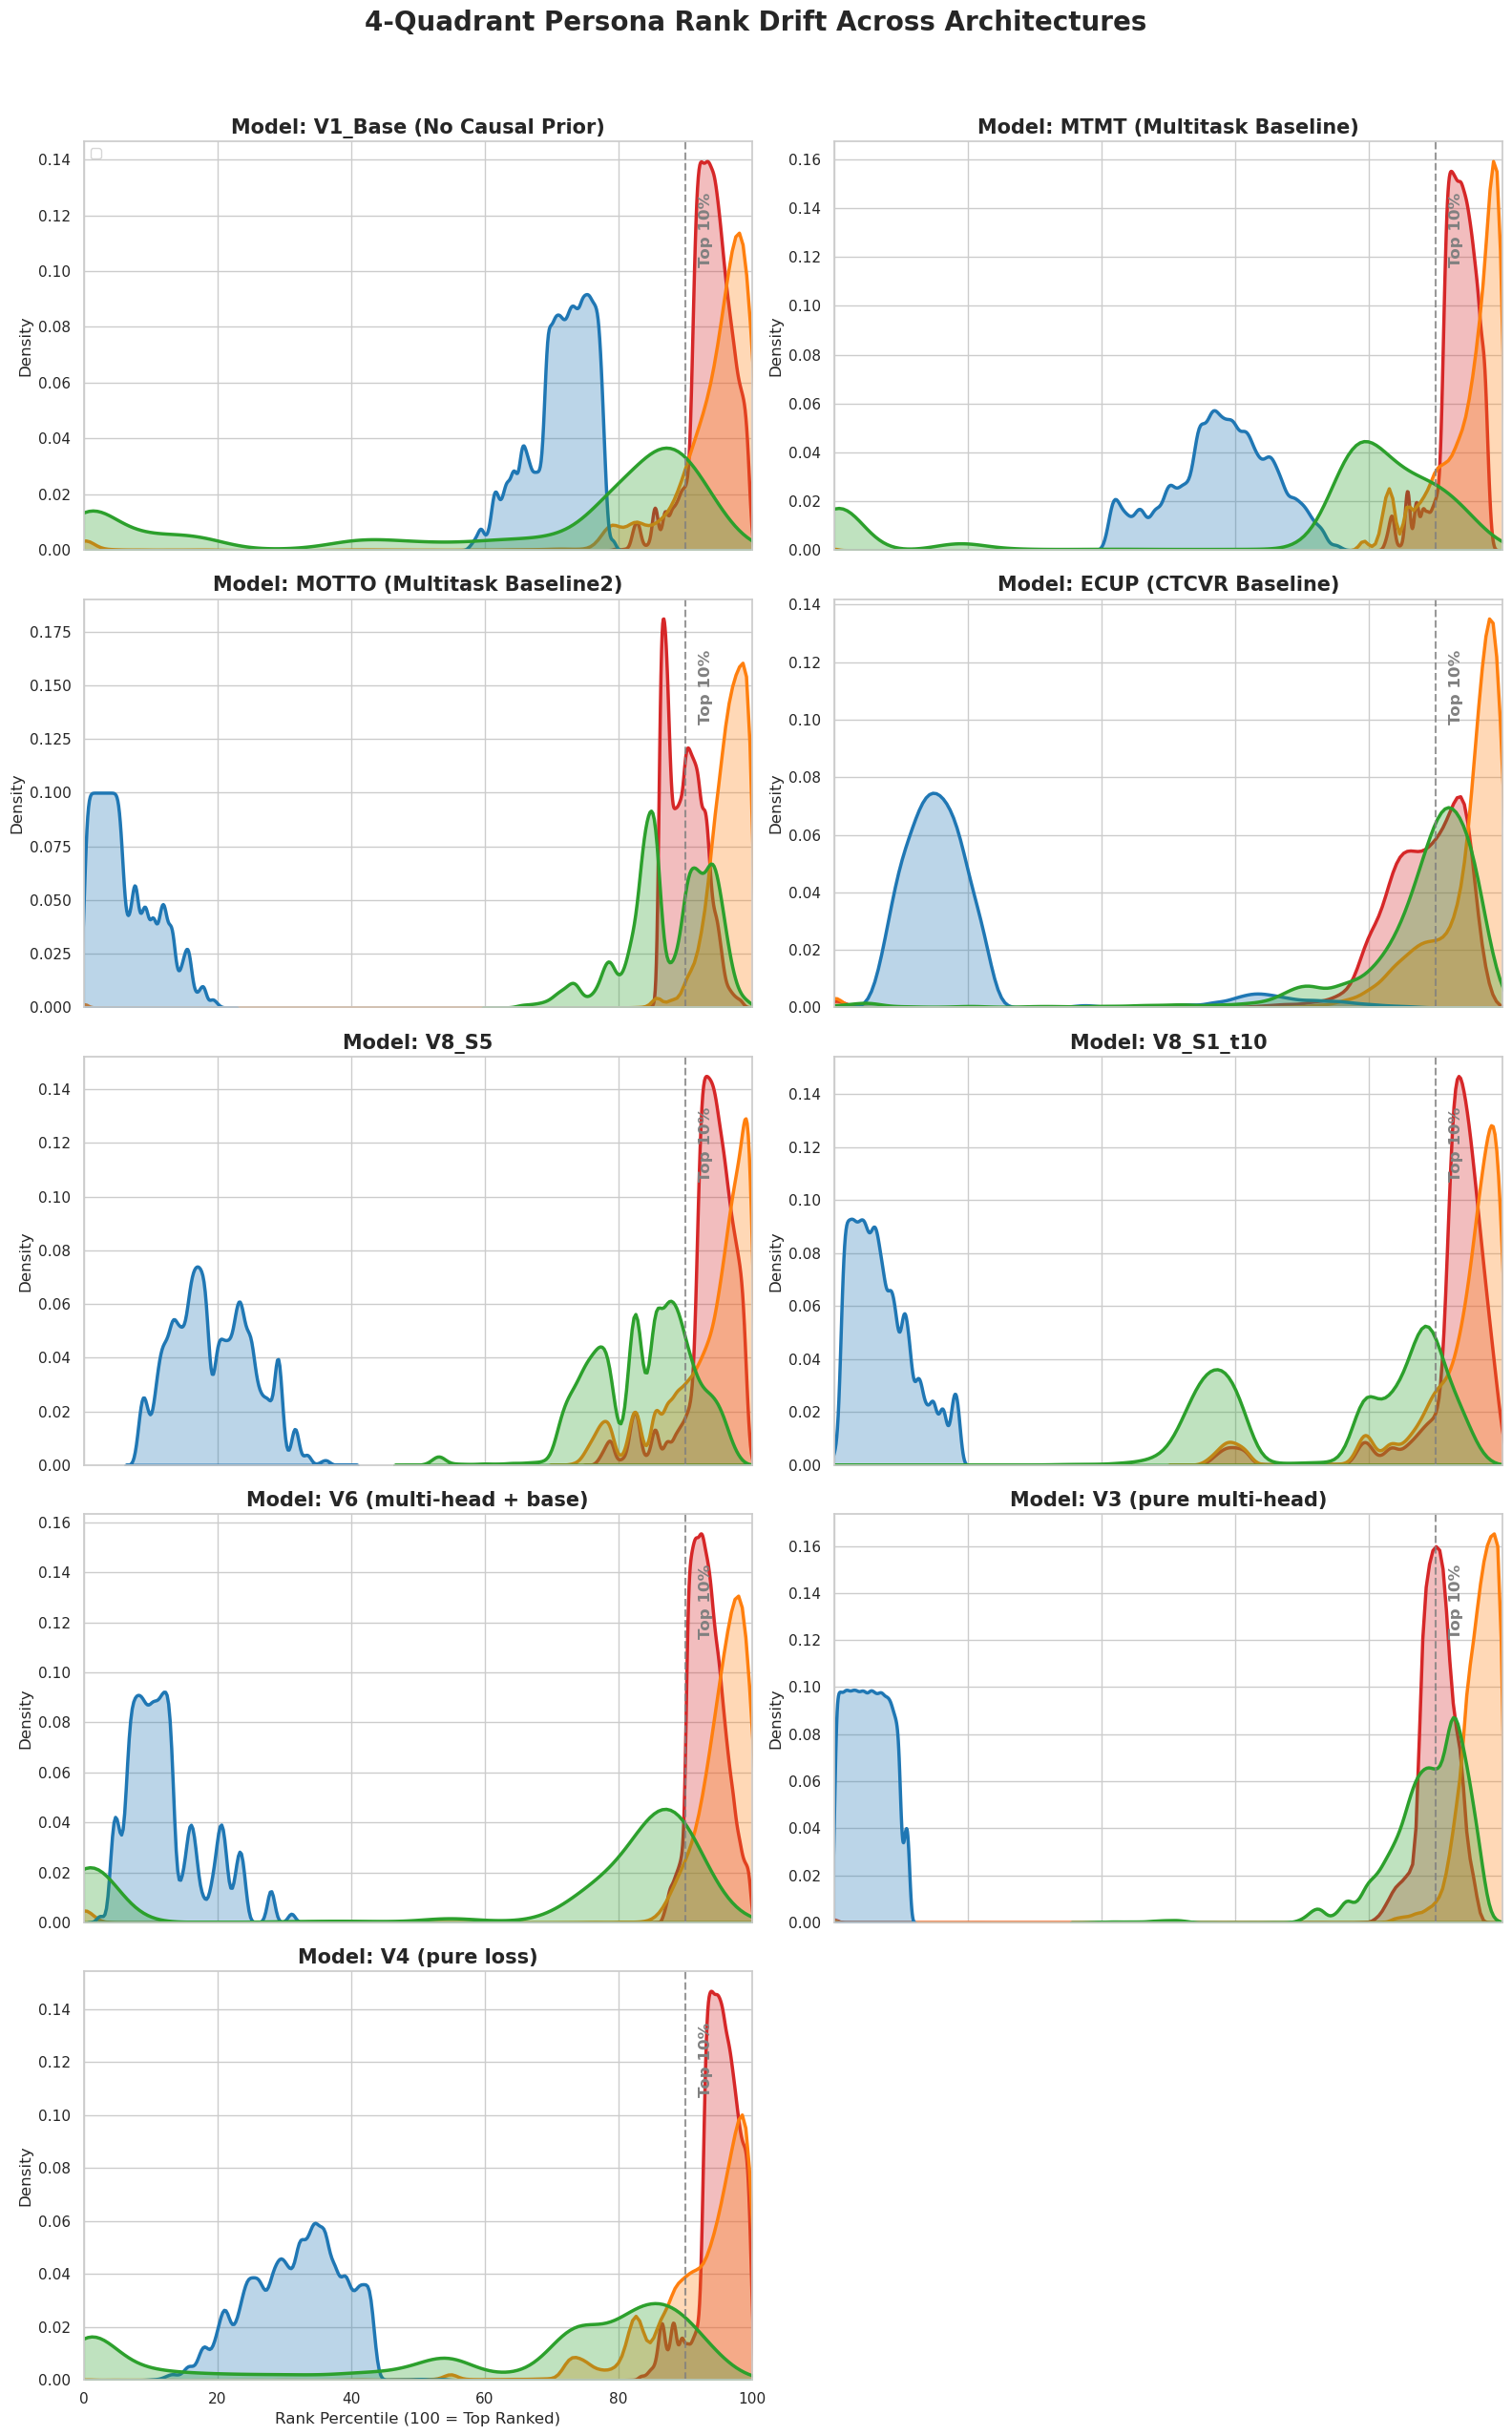

In [15]:
import os
import glob
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 0. 自动路径嗅探
# ==========================================
def resolve_path(pattern):
    files = glob.glob(pattern, recursive=True)
    if not files:
        print(f"⚠️ 找不到文件跳过: {pattern}")
        return None
    return files[0]

# ==========================================
# 1. 核心分析类：四象限微观追踪器
# ==========================================
class QuadrantDriftGridAnalyzer:
    def __init__(self, c_pattern, model_paths_dict):
        sns.set_theme(style="whitegrid")
        print("\n📥 Loading external C-Prior as the Absolute Referee...")
        
        c_path = resolve_path(c_pattern)
        if not c_path:
            raise ValueError("C-Prior path is required!")
        self.df_c = pd.read_csv(c_path)
        
        self.p_always = self.df_c['y0_prob'] 
        self.p_comp = np.clip(self.df_c['y1_prob'] - self.df_c['y0_prob'], 0, None)
        self.p_never = np.clip(1.0 - self.df_c['y1_prob'], 0, None) 

        self.models_data = {}
        print("📥 Loading and ranking models...")
        for name, pattern in model_paths_dict.items():
            path = resolve_path(pattern)
            if path:
                df = pd.read_csv(path)
                rank_pct = df['uplift_pred'].rank(pct=True) * 100
                self.models_data[name] = rank_pct
                print(f"   - Successfully loaded: {name}")

        self._assign_4_personas()

    def _assign_4_personas(self):
        """核心修改：切分出 4 个严格物理隔离的象限"""
        print("🧬 Tagging 4 distinct personas (Pure AT, Pure CO, AT&CO, NT)...")
        
        self.label_pure_at = 'Pure Click-Bait [Pure AT]'
        self.label_pure_co = 'Pure Persuadable [Pure CO]'
        self.label_both = 'High-Active & Sensitive [AT & CO]'
        self.label_nt = 'Never-Taker [NT]'
        
        self.personas = pd.Series('Neutral', index=self.df_c.index)
        
        # 统一的极值判定线
        th_always = self.p_always.quantile(0.90)
        th_comp = self.p_comp.quantile(0.90)
        th_never = self.p_never.quantile(0.90) 
        
        # 基础布尔掩码
        is_at = self.p_always >= th_always
        is_comp = self.p_comp >= th_comp
        
        # 1. 双料高潜 (橙色)
        mask_both = is_at & is_comp
        # 2. 纯正羊毛党 (红色)
        mask_pure_at = is_at & (~is_comp)
        # 3. 纯正金子 (绿色)
        mask_pure_co = is_comp & (~is_at)
        # 4. 绝缘体 (蓝色)
        mask_nt = (self.p_never >= th_never) & (~is_at) & (~is_comp)
        
        self.personas.loc[mask_nt] = self.label_nt
        self.personas.loc[mask_pure_at] = self.label_pure_at
        self.personas.loc[mask_pure_co] = self.label_pure_co
        self.personas.loc[mask_both] = self.label_both
        
        print(f"   => {self.label_pure_at}: {mask_pure_at.sum()} users")
        print(f"   => {self.label_pure_co}: {mask_pure_co.sum()} users")
        print(f"   => {self.label_both}: {mask_both.sum()} users")
        print(f"   => {self.label_nt}: {mask_nt.sum()} users")

    def plot_grid(self):
        model_names = list(self.models_data.keys())
        num_models = len(model_names)
        
        if num_models == 0: return
            
        cols = 2
        rows = math.ceil(num_models / cols)
        
        fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), sharex=True)
        fig.suptitle('4-Quadrant Persona Rank Drift Across Architectures', fontsize=20, fontweight='bold', y=1.02)
        
        axes_flat = axes if rows == 1 else axes.flatten()
            
        # 4色调色板
        palette = {
            self.label_pure_at: '#d62728', # 红：必须被踩下去的羊毛党
            self.label_pure_co: '#2ca02c', # 绿：必须保住的纯金子
            self.label_both: '#ff7f0e',    # 橙：必须捧在手心的高活易感人群
            self.label_nt: '#1f77b4'       # 蓝：必须垫底的绝缘体
        }
        
        target_personas = [self.label_pure_at, self.label_pure_co, self.label_both, self.label_nt]
        mask = self.personas.isin(target_personas)
        
        for i, ax in enumerate(axes_flat):
            if i < num_models:
                m_name = model_names[i]
                rank_data = self.models_data[m_name]
                
                plot_df = pd.DataFrame({
                    'Rank Percentile': rank_data[mask],
                    'Persona': self.personas[mask]
                })
                
                sns.kdeplot(data=plot_df, x='Rank Percentile', hue='Persona', fill=True, 
                            ax=ax, palette=palette, alpha=0.3, linewidth=2.5, common_norm=False)
                
                ax.set_title(f"Model: {m_name}", fontsize=15, fontweight='bold')
                ax.set_xlabel('Rank Percentile (100 = Top Ranked)', fontsize=12)
                ax.set_xlim(0, 100)
                
                ax.axvline(90, color='gray', linestyle='--', alpha=0.8)
                ax.text(92, ax.get_ylim()[1]*0.7, "Top 10%", rotation=90, color='gray', fontweight='bold')
                
                if i == 0:
                    ax.legend(loc='upper left', fontsize=10)
                else:
                    if ax.get_legend(): ax.get_legend().remove() 
            else:
                fig.delaxes(ax)

        plt.tight_layout()
        print("✅ Rendering plot... (Close the plot window to continue)")
        plt.show()

# ==========================================
# 2. 启动区
# ==========================================
if __name__ == "__main__":
    C_PATH = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    
    MODELS_TO_COMPARE = {
        "V1_Base (No Causal Prior)": "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv",
        "MTMT (Multitask Baseline)": "./results/criteo/train_y/MTMT/**/test_dist.csv",
        "MOTTO (Multitask Baseline2)": "./results/criteo/train_y/MOTTO/**/test_dist.csv", # 注意这里改成了 MOTTO
        "ECUP (CTCVR Baseline)": "./results/criteo/train_y/ECUP/**/test_dist.csv",
        "V8_S5": "./results/criteo/train_y/TARNET/y_v8_s5/**/test_dist.csv",
        "V8_S1_t10": "./results/criteo/train_y/TARNET/y_v8_s1_t10/**/test_dist.csv",
        "V6 (multi-head + base)": "./results/criteo/train_y/TARNET/y_v6_res_moe/**/test_dist.csv",
        "V3 (pure multi-head)": "./results/criteo/train_y/TARNET/y_v3_moe/**/test_dist.csv",
        "V4 (pure loss)": "./results/criteo/train_y/TARNET/y_v4_loss_strata/**/test_dist.csv",
    }
    
    analyzer = QuadrantDriftGridAnalyzer(C_PATH, MODELS_TO_COMPARE)
    analyzer.plot_grid()

In [19]:
# 新发现！！！！：纯Always taker确实不好，uplift很小，但所有模型都没做好，包括我们的，也包括纳入中介的。为什么呢。

In [17]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def resolve_path(pattern):
    files = glob.glob(pattern, recursive=True)
    if not files:
        print(f"⚠️ 找不到文件跳过: {pattern}")
        return None
    return files[0]

class MultiModelPersonaAuditor:
    def __init__(self, c_pattern, models_dict, output_dir="0418_persona_audit"):
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        sns.set_theme(style="whitegrid")
        
        print("\n📥 加载上帝账本 (C-Prior)...")
        self.c_path = resolve_path(c_pattern)
        self.df_c = pd.read_csv(self.c_path)
        self.models_dict = models_dict

    def process_model(self, name, df, is_referee=False):
        """核心：四象限切分 + 预测与真实 ATE 对账"""
        # 1. 提取当前模型的心智分数
        if is_referee:
            p_at_score = df['y0_prob']
            p_co_score = np.clip(df['y1_prob'] - df['y0_prob'], 0, None)
            p_nt_score = np.clip(1.0 - df['y1_prob'], 0, None)
        else:
            p_at_score = df['c0_prob'] if 'c0_prob' in df.columns else self.df_c['y0_prob']
            p_co_score = df['c_uplift_pred'] if 'c_uplift_pred' in df.columns else (df['c1_prob'] - df['c0_prob'] if 'c1_prob' in df.columns else np.clip(self.df_c['y1_prob'] - self.df_c['y0_prob'], 0, None))
            p_nt_score = np.clip(1.0 - df['c1_prob'], 0, None) if 'c1_prob' in df.columns else np.clip(1.0 - self.df_c['y1_prob'], 0, None)

        # 2. 四象限打标签
        df_eval = df.copy()
        df_eval['p_at_internal'] = p_at_score
        df_eval['p_co_internal'] = p_co_score
        df_eval['Persona'] = 'Neutral'
        
        th_at = p_at_score.quantile(0.90)
        th_co = p_co_score.quantile(0.90)
        th_nt = p_nt_score.quantile(0.90)

        is_at_pool = p_at_score >= th_at
        is_co_pool = p_co_score >= th_co
        is_nt_pool = p_nt_score >= th_nt

        # 严格切分逻辑
        df_eval.loc[is_at_pool & ~is_co_pool, 'Persona'] = 'Pure AT'
        df_eval.loc[is_co_pool & ~is_at_pool, 'Persona'] = 'Pure CO'
        df_eval.loc[is_at_pool & is_co_pool, 'Persona'] = 'AT & CO'
        df_eval.loc[is_nt_pool & ~is_at_pool & ~is_co_pool, 'Persona'] = 'Never-Taker'

        # 3. 计算对账数据
        results = []
        target_personas = ['Pure AT', 'Pure CO', 'AT & CO', 'Never-Taker']
        
        for p in target_personas:
            group = df_eval[df_eval['Persona'] == p]
            if len(group) == 0: continue
            
            t1, t0 = group[group['t'] == 1], group[group['t'] == 0]
            
            # 真实 ATE (Ground Truth)
            base_click = t0['c_true'].mean() if len(t0)>0 else 0
            c_ate = (t1['c_true'].mean() if len(t1)>0 else 0) - base_click
            y_ate = (t1['y_true'].mean() if len(t1)>0 else 0) - (t0['y_true'].mean() if len(t0)>0 else 0)
            
            # 模型预测的平均心智 (Mental States)
            pred_p_at = group['p_at_internal'].mean()
            pred_p_co = group['p_co_internal'].mean()
            
            results.append({
                'Persona': p,
                'Pop': len(group),
                'Pred_P_AT': pred_p_at,
                'Pred_P_CO': pred_p_co,
                'Real_Base_C': base_click,
                'Real_C_ATE': c_ate,
                'Real_Y_ATE': y_ate
            })
            
        stats_df = pd.DataFrame(results)
        
        print("\n" + "="*110)
        print(f"🏆 [{name}] 深度对账表 (四象限切分 + 预测 vs 真实)")
        print("="*110)
        print(stats_df.to_string(index=False))
        print("="*110)

        self.plot_audit(name, stats_df)

    def plot_audit(self, name, df):
        """可视化：心智与现实的错位"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f'Causal Audit: {name}', fontsize=16, fontweight='bold')
        
        x = np.arange(len(df))
        width = 0.3
        
        # 左图：预测心智 (Pred P_AT vs Pred P_CO)
        ax1.bar(x - width/2, df['Pred_P_AT'], width, label='Predicted P_AT', color='#ff9999', edgecolor='black')
        ax1.bar(x + width/2, df['Pred_P_CO'], width, label='Predicted P_CO', color='#99ff99', edgecolor='black')
        ax1.set_title('Internal Mental States (Scores)', fontweight='bold')
        ax1.set_xticks(x)
        ax1.set_xticklabels(df['Persona'])
        ax1.legend()

        # 右图：真实表现 (C_ATE vs Y_ATE)
        ax2.bar(x - width/2, df['Real_C_ATE'], width, label='Real C_ATE', color='#d62728', alpha=0.7, edgecolor='black')
        ax2.bar(x + width/2, df['Real_Y_ATE']*10, width, label='Real Y_ATE (x10)', color='#2ca02c', alpha=0.7, edgecolor='black')
        ax2.set_title('External Real Performance (ATE)', fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(df['Persona'])
        ax2.legend()
        
        plt.tight_layout()
        safe_name = name.split()[0].replace("/", "_")
        plt.savefig(os.path.join(self.output_dir, f"Audit_{safe_name}.png"), dpi=300)
        plt.close()

    def run(self):
        self.process_model("Referee", self.df_c, is_referee=True)
        for name, pattern in self.models_dict.items():
            path = resolve_path(pattern)
            if path:
                self.process_model(name, pd.read_csv(path))

if __name__ == "__main__":
    C_PATH = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    MODELS = {
        "MTMT": "./results/criteo/train_y/MTMT/**/test_dist.csv",
        "MOTTO": "./results/criteo/train_y/MOTTO/**/test_dist.csv",
        "ECUP": "./results/criteo/train_y/ECUP/**/test_dist.csv"
    }
    
    auditor = MultiModelPersonaAuditor(C_PATH, MODELS)
    auditor.run()


📥 加载上帝账本 (C-Prior)...

🏆 [Referee] 深度对账表 (四象限切分 + 预测 vs 真实)
    Persona    Pop  Pred_P_AT  Pred_P_CO  Real_Base_C  Real_C_ATE  Real_Y_ATE
    Pure AT  55773    0.24573    0.00384      0.23732     0.00751     0.00063
    Pure CO  55773    0.05679    0.04412      0.06139     0.04509     0.00149
    AT & CO  84023    0.32947    0.07598      0.34491     0.06668     0.01216
Never-Taker 139796    0.00213    0.00000      0.00145     0.00051    -0.00000

🏆 [MTMT] 深度对账表 (四象限切分 + 预测 vs 真实)
    Persona    Pop  Pred_P_AT  Pred_P_CO  Real_Base_C  Real_C_ATE  Real_Y_ATE
    Pure AT  13668    0.16190    0.01855      0.15478     0.00409     0.00118
    Pure CO  13668    0.10391    0.03391      0.14387     0.03853    -0.00033
    AT & CO 126128    0.31577    0.06030      0.30374     0.05368     0.00933
Never-Taker 139796    0.00227   -0.00012      0.00230     0.00018    -0.00012

🏆 [MOTTO] 深度对账表 (四象限切分 + 预测 vs 真实)
    Persona    Pop  Pred_P_AT  Pred_P_CO  Real_Base_C  Real_C_ATE  Real_Y_ATE
    Pure A

In [21]:
import os
import glob
import pandas as pd
import numpy as np

# ==========================================
# 0. 基础工具：路径解析
# ==========================================
def resolve_path(pattern):
    """自动解析带 ** 通配符的路径，找到最新的 csv"""
    files = glob.glob(pattern, recursive=True)
    if not files:
        print(f"⚠️ 找不到文件跳过: {pattern}")
        return None
    return files[0]

# ==========================================
# 1. 核心审计类：VIP Slices Auditor (Sorted Edition)
# ==========================================
class VIPTrafficSlicesAuditor:
    def __init__(self, c_pattern, models_dict):
        print("\n📥 正在加载上帝账本 (C-Prior Model)...")
        c_path = resolve_path(c_pattern)
        if not c_path:
            raise ValueError("必须提供 C 模型的路径作为上帝账本！")
            
        self.df_master = pd.read_csv(c_path)
        
        # --- 预计算上帝视角的“心智序” ---
        self.df_master['p_at_score'] = self.df_master['y0_prob']
        self.df_master['p_co_score'] = np.clip(self.df_master['y1_prob'] - self.df_master['y0_prob'], 0, None)
        
        # 转换为百分位排名 (0-100)
        self.df_master['p_at_rank'] = self.df_master['p_at_score'].rank(pct=True) * 100
        self.df_master['p_co_rank'] = self.df_master['p_co_score'].rank(pct=True) * 100
        
        # 判定硬标签羊毛党
        th_at = self.df_master['p_at_score'].quantile(0.90)
        self.df_master['is_AT'] = self.df_master['p_at_score'] >= th_at
        
        self.models_dict = models_dict
        self.results = []

    def _calc_slice_stats(self, df_subset, model_name, slice_name):
        """计算核心指标"""
        if len(df_subset) == 0: return None
            
        t1, t0 = df_subset[df_subset['t'] == 1], df_subset[df_subset['t'] == 0]
        
        y_ate = (t1['y_true'].mean() if len(t1) > 0 else 0) - (t0['y_true'].mean() if len(t0) > 0 else 0)
        c_ate = (t1['c_true'].mean() if len(t1) > 0 else 0) - (t0['c_true'].mean() if len(t0) > 0 else 0)
        at_ratio = df_subset['is_AT'].mean() * 100 
        avg_pco_rank = df_subset['p_co_rank'].mean()
        avg_pat_rank = df_subset['p_at_rank'].mean()
        
        return {
            'Model': model_name,
            'Slice': slice_name,
            'Y-ATE ⬆️': y_ate,
            'C-ATE ⬇️': c_ate,
            'AT% ⬇️': at_ratio,
            'Avg PCO序': avg_pco_rank,
            'Avg PAT序': avg_pat_rank
        }

    def audit_models(self):
        slices = [(0.00, 0.05, "Top 0-5%"), (0.05, 0.10, "Top 5-10%")]
        
        for name, pattern in self.models_dict.items():
            path = resolve_path(pattern)
            if not path: continue
            df_model = pd.read_csv(path)
            self.df_master['m_score'] = df_model['uplift_pred']
            self.df_master['m_pos'] = self.df_master['m_score'].rank(pct=True, ascending=False)
            
            for start, end, label in slices:
                df_slice = self.df_master[(self.df_master['m_pos'] >= start) & (self.df_master['m_pos'] < end)]
                stats = self._calc_slice_stats(df_slice, name, label)
                if stats: self.results.append(stats)
            
        self.report_df = pd.DataFrame(self.results)
        
        # --- 核心改动：排序逻辑 ---
        # 先按 Slice 升序（0-5% 在前），再按 Y-ATE 降序（最强的在上面）
        self.report_df = self.report_df.sort_values(by=['Slice', 'Y-ATE ⬆️'], ascending=[True, False])
        
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        pd.set_option('display.float_format', '{:.5f}'.format)
        
        print("\n" + "="*135)
        print("🏆 【分段对账单 - 胜率排序版】各模型核心流量 ATE 审计")
        print("-" * 135)
        print(self.report_df.to_string(index=False))
        print("="*135)

# ==========================================
# 2. 启动执行
# ==========================================
if __name__ == "__main__":
    C_PATH = "./results/criteo/train_c/TARNET/c_v1_base/**/test_dist.csv"
    
    MODELS_TO_COMPARE = {
        "V1_Base": "./results/criteo/train_y/TARNET/y_v1_base/**/test_dist.csv",
        "MTMT": "./results/criteo/train_y/MTMT/**/test_dist.csv",
        "MOTTO": "./results/criteo/train_y/MTMT/**/test_dist.csv", # 路径同MTMT
        "ECUP": "./results/criteo/train_y/ECUP/**/test_dist.csv",
        "V8_S5": "./results/criteo/train_y/TARNET/y_v8_s5/**/test_dist.csv",
        "V8_S1_t10": "./results/criteo/train_y/TARNET/y_v8_s1_t10/**/test_dist.csv",
        "V6_Res_MoE": "./results/criteo/train_y/TARNET/y_v6_res_moe/**/test_dist.csv",
        "V3_MoE": "./results/criteo/train_y/TARNET/y_v3_moe/**/test_dist.csv",
        "V4_Loss": "./results/criteo/train_y/TARNET/y_v4_loss_strata/**/test_dist.csv",
    }
    
    auditor = VIPTrafficSlicesAuditor(C_PATH, MODELS_TO_COMPARE)
    auditor.audit_models()


📥 正在加载上帝账本 (C-Prior Model)...

🏆 【分段对账单 - 胜率排序版】各模型核心流量 ATE 审计
---------------------------------------------------------------------------------------------------------------------------------------
     Model     Slice  Y-ATE ⬆️  C-ATE ⬇️   AT% ⬇️  Avg PCO序  Avg PAT序
V6_Res_MoE  Top 0-5%   0.01471   0.05733 99.59512  89.23509  97.25596
 V8_S1_t10  Top 0-5%   0.01334   0.05893 98.82828  82.70681  96.74896
    V3_MoE  Top 0-5%   0.01278   0.07458 92.16418  96.77252  95.91145
      ECUP  Top 0-5%   0.01266   0.07683 83.73344  95.42659  93.97548
   V4_Loss  Top 0-5%   0.01210   0.05116 99.34332  73.03983  96.31260
      MTMT  Top 0-5%   0.01207   0.06673 97.44052  86.46799  96.48968
     MOTTO  Top 0-5%   0.01207   0.06673 97.44052  86.46799  96.48968
     V8_S5  Top 0-5%   0.01094   0.06291 96.91975  80.40703  96.25680
   V1_Base  Top 0-5%   0.01073   0.06167 98.21881  82.69293  96.55766
   V1_Base Top 5-10%   0.00530   0.02882 73.46276  59.02958  92.10853
     V8_S5 Top 5-10%   0.00445

: 

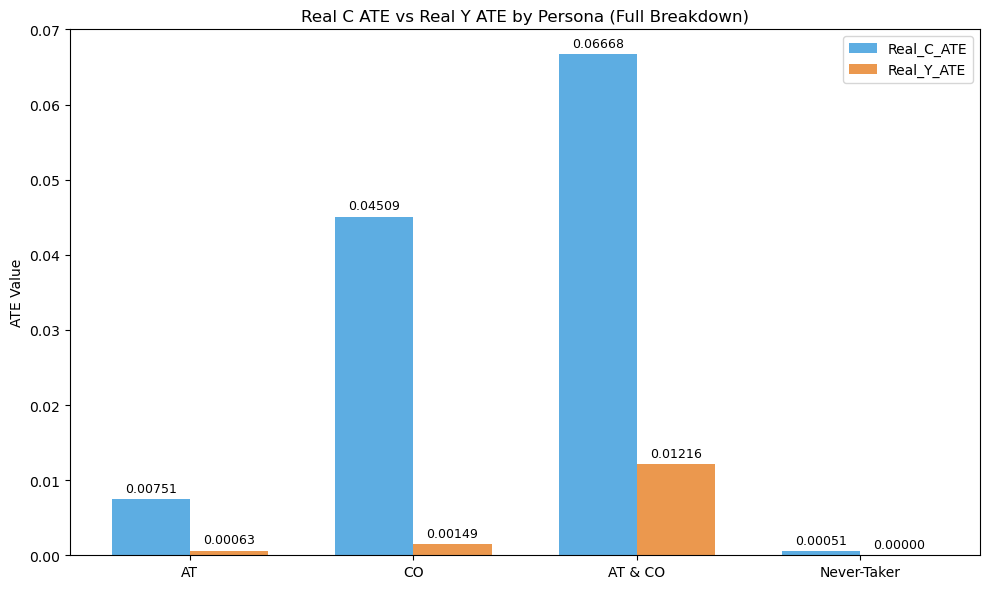

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 准备数据
personas = ['AT', 'CO', 'AT & CO', 'Never-Taker']
c_ate = [0.00751, 0.04509, 0.06668, 0.00051]
y_ate = [0.00063, 0.00149, 0.01216, 0.00000]  # 原数据中 Never-Taker 为 -0.00000

x = np.arange(len(personas))  # 标签位置
width = 0.35  # 柱状图宽度

fig, ax = plt.subplots(figsize=(10, 6))

# 绘制柱状图
rects1 = ax.bar(x - width/2, c_ate, width, label='Real_C_ATE', color='#5DADE2')
rects2 = ax.bar(x + width/2, y_ate, width, label='Real_Y_ATE', color='#EB984E')

# 添加文本说明
ax.set_ylabel('ATE Value')
ax.set_title('Real C ATE vs Real Y ATE by Persona (Full Breakdown)')
ax.set_xticks(x)
ax.set_xticklabels(personas)
ax.legend()

# 在柱子上标注数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.5f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3点纵向偏移
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()